# SARIMA

Se desarrolla un modelo ARIMA estacional aplicando los pasos definidos mediante la metodología Box-Jenkins. Los datos provienen de SMARD - base de datos que contiene información relacionada al consumo de energía en Alemania.

Fuente: https://www.smard.de/en/downloadcenter/download-market-data/?downloadAttributes=%7B"selectedCategory":2,"selectedSubCategory":5,"selectedRegion":"DE","selectedFileType":"CSV","from":1420066800000,"to":1767221999999%7D)''

In [1]:
import numpy as np
import pandas as pd
import itertools
import statsmodels.api as sm
import time
import json
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.tsaplots import acf, pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
from scipy.signal import periodogram, welch
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
warnings.filterwarnings('ignore')
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")


Se definen las funciones requeridas para la validar la estacionariedad de la serie (aplicación del cliterio de Dickey-Fuller y gráfica de la ACF y la PACF)

In [2]:
def check_stationarity(ts):
    result = adfuller(ts, autolag='AIC')
    p_value = result[1]
    print(f"ADF Statistic: {result[0]:.16f}")
    print(f"p-value: {p_value:.16f}")
    print('Estacionaria' if p_value < 0.05 else 'No estacionaria')

def plot_acf_pacf(ts, n_lags=200, title_graph=["ACF", "PACF"]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,6))

    plot_acf(
        ts,
        ax=ax1,
        lags=n_lags,
        alpha=0.05,
        vlines_kwargs={"colors": "black"},
        marker="o",
        color="black",
        markersize=4,
        title=title_graph[0]
    )

    plot_pacf(
        ts,
        ax=ax2,
        lags=n_lags,
        method="ywm",
        alpha=0.05,
        vlines_kwargs={"colors": "black"},
        marker="o",
        color="black",
        markersize=4,
        title=title_graph[1]
    )

    # cambiar color de intervalos de confianza
    for ax in [ax1, ax2]:
        for collection in ax.collections:
            collection.set_facecolor("lightgray")
            collection.set_alpha(0.6)

    return plt.show()

Se cargan los datos (inicialmente los datos estaban dados en días, lo que se hizo fue tomar la media semanal de las observaciones, dado que se tomaron 10 años de datos. Este proceso ya fue realizado antes de cargar los datos. La fecha mostrada es el lunes de cada semana). El orden de las observaciones está dado en millones

In [3]:
data_demand =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_demand = pd.DataFrame(data_demand.copy()) # copia del df de precios de cierre como df
df_data_demand["Start date"] = pd.to_datetime(df_data_demand["Start date"]) # conversión a formato fecha
df_data_close = df_data_demand.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()


,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


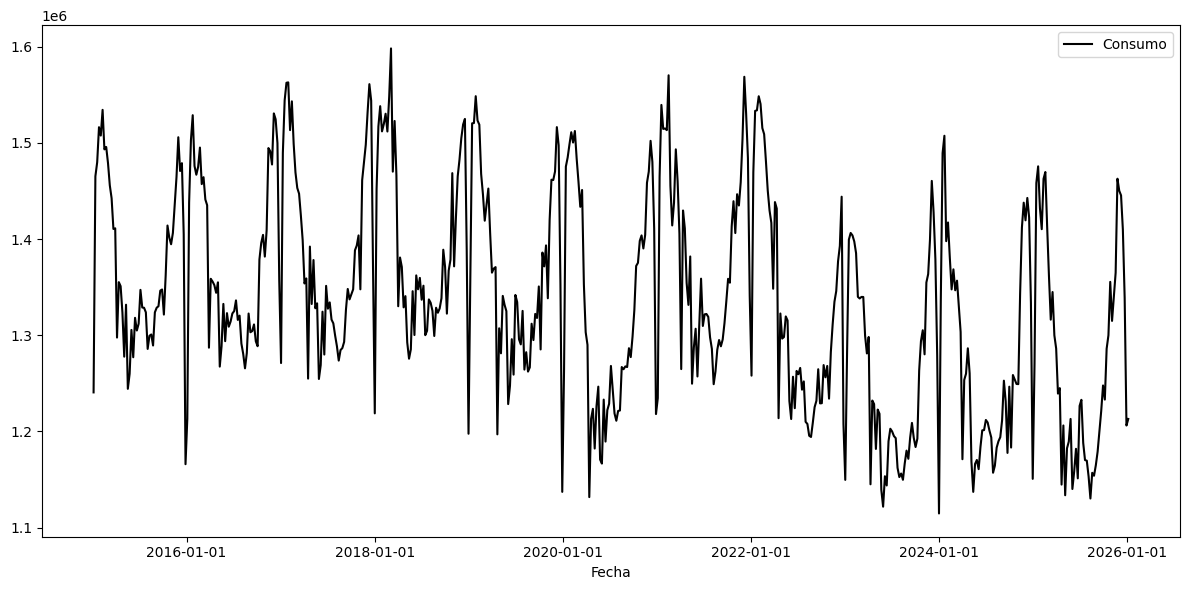

In [4]:
# # se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
plt.plot(df_data_close["Start date"], df_data_close["value"], label="Consumo", color="black")
#plt.plot(df_data_close2["Date"], df_data_close2["Value"], color="blue")
plt.xlabel("Fecha")
#plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

Primeramente se separan los datos en los conjuntos train y test para validar el rendimiento del modelo final mediante datos no vistos. Se toma el 90% del total de datos como conjunto de entrenamiento y el 10% restante como conjunto de validación. Se realiza dicha división y se grafica

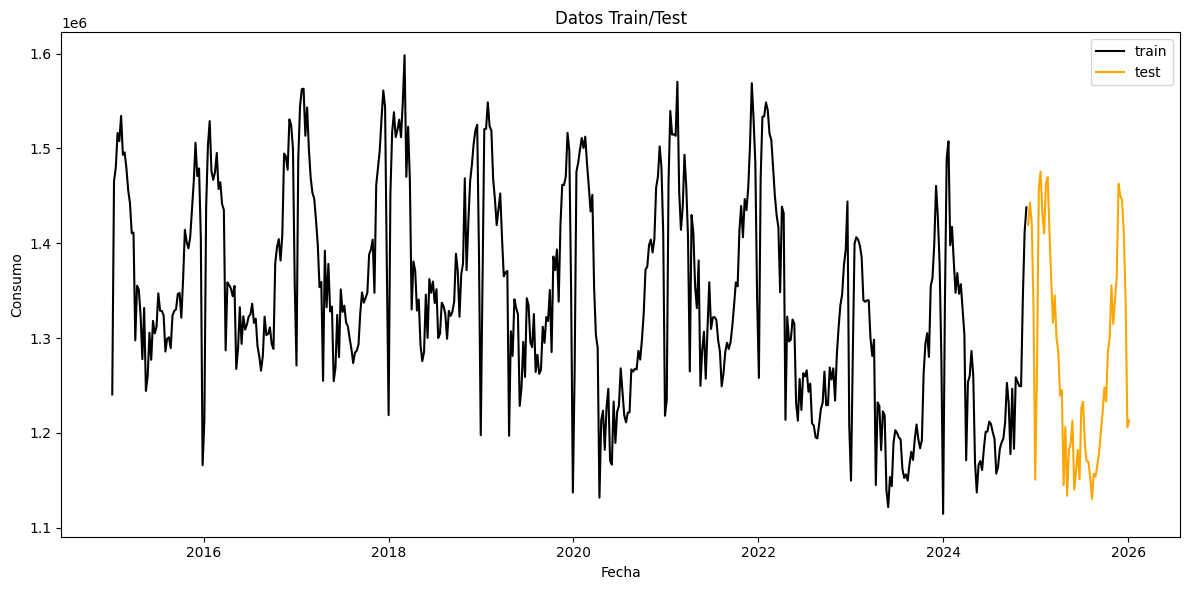

In [5]:
# se divide en train/test y se trabaja con train para fijar el modelo
train, test = train_test_split(df_data_close, test_size=0.1, shuffle=False)
train = train.sort_values(by="Start date")
test = test.sort_values(by="Start date")

# gráfica train/test
plt.figure(figsize=(12,6))
plt.plot(train["Start date"], train["value"], label="train", color="black")
plt.plot(test["Start date"], test["value"], label="test", color="orange")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()
plt.title("Datos Train/Test")
plt.tight_layout()
#plt.grid(True)
plt.show()

El estudio de las propiedades estadísticas se hará en el conjunto de train, se fijará un modelo y luego se generarán predicciones a partir de dicho modelo para compararlas con el conjunto de testeo

In [6]:
print(f"train len: {len(train)}")
print(f"test len: {len(test)}")

train len: 517
test len: 58


In [7]:
# calculamos la media de la serie train
train_data_mean = train["value"].mean()
train_data_mean

1344470.7318181817

respecto al conjunto de datos de entrenamiento logra apreciarse que no existen tendencias relevantes en el conjunto TrainnG, ni variaciones significativas en la dispersión de la serie. Además la serie oscila aproximandamente alrededor de la media, lo que sugiere que la serie es estacionaria. Al no tener comportamientos relevantes de tendencia o variaciones relevantes, la serie en este caso no requiere transformaciones estabilizadoras de varianza. Para validar la estacionariedad de la serie, se aplica el criterio de Dickey Fuller para examinar la presencia de raíces unitarias

In [8]:
# se valida estacionariedad de la serie
check_stationarity(train["value"])

ADF Statistic: -5.1166898303901229
p-value: 0.0000129751898812
Estacionaria


Se tiene que el valor p del test es menor a 0.05, lo que sugiere que no hay presencia de raíces unitarias y por ende la serie TrainG es estacionaria. Sin embargo, se examina el caso d = 1 para descartar la leve tendencia observada en la serie. Así, aunque el test de Dickey-Fuller indica que la serie por defecto es estacionaria, se examina el caso d = 1.

Ahora se examina el comportamiento de la ACF y la PACF de la serie tanto para la serie normal como diferenciada, para validar si se requiere remover alguna componente estacional dado que el test de Dickey-Fuller no contempla diferenciación estacional

Ahora se examina la periodicidad de la serie, dado el comportamiento cílico que parece resaltar en la serie. Para validar si tiene una frecuencia significativa, se calcula su periodograma

Periodo dominante estimado: 51.70


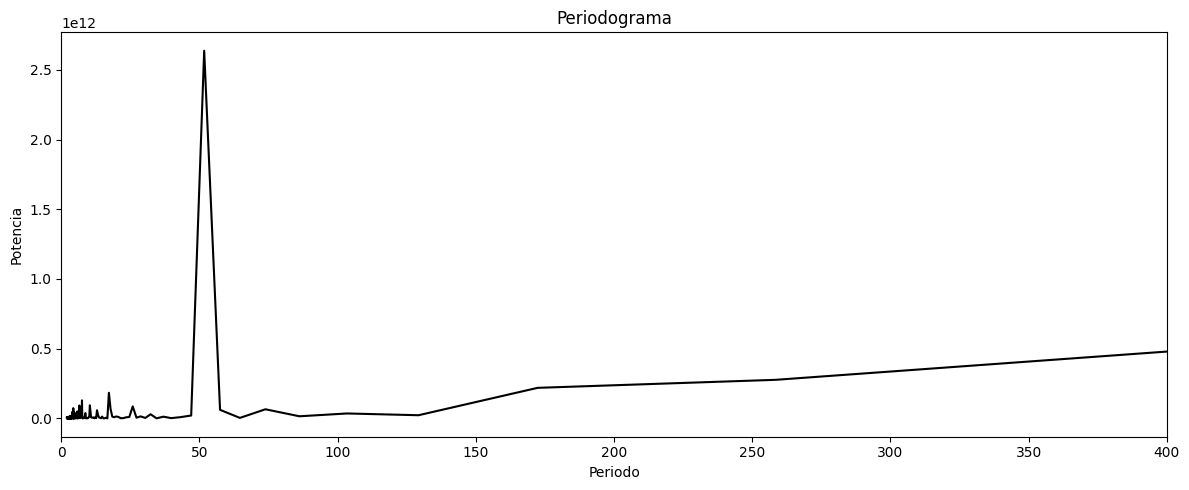

In [9]:
#periodograma
# 1. Preparación


train_copy = train.sort_values("Start date").copy()
train_copy["Start date"] = pd.to_datetime(train_copy["Start date"])
train_copy = train_copy.set_index("Start date")

# Ajustar frecuencia
train_copy = train_copy.asfreq("W-MON") # frecuencia semanal con inicio el lunes (así se agrupo)

serie = train_copy["value"].dropna().values

# 2. Periodograma clásico
fs = 1  # 1 observación por unidad temporal
frequencies, power = periodogram(serie, fs=fs)


# 3. Periodograma en términos de periodo
frequencies_nonzero = frequencies[1:]
power_nonzero = power[1:]

periods = 1 / frequencies_nonzero

# Detectar periodo dominante
idx_max = np.argmax(power_nonzero)
periodo_dominante = periods[idx_max]

print(f"Periodo dominante estimado: {periodo_dominante:.2f}")


# 4. Welch (suavizado)
frequencies_w, power_w = welch(serie, fs=1, nperseg=min(256, len(serie)))
frequencies_w_nz = frequencies_w[1:]
power_w_nz = power_w[1:]
periods_w = 1 / frequencies_w_nz


# 5. Gráficas

plt.figure(figsize=(12,5))
#plt.subplot(1,2,1)
plt.plot(periods, power_nonzero, color="black")
plt.title("Periodograma")
plt.xlabel("Periodo")
plt.ylabel("Potencia")
plt.xlim(0, min(400, periods.max()))
#plt.grid(True)

#plt.subplot(1,2,2)
#plt.plot(periods_w, power_w_nz)
#plt.title("Welch Periodogram")
##plt.xlabel("Periodo")
#plt.ylabel("Potencia")
#plt.xlim(0, min(400, periods_w.max()))
#plt.grid(True)

plt.tight_layout()
plt.show()

De forma preliminar se concluye que una frecuencia relevante de la serie ocurre en aprox s = 52 semanas, lo que es consistente con el comportamiento cíclico visto dada la naturaleza de la serie. Ahora se mira la ACF y la PACF de la serie para examinar dicho comportamiento cíclico

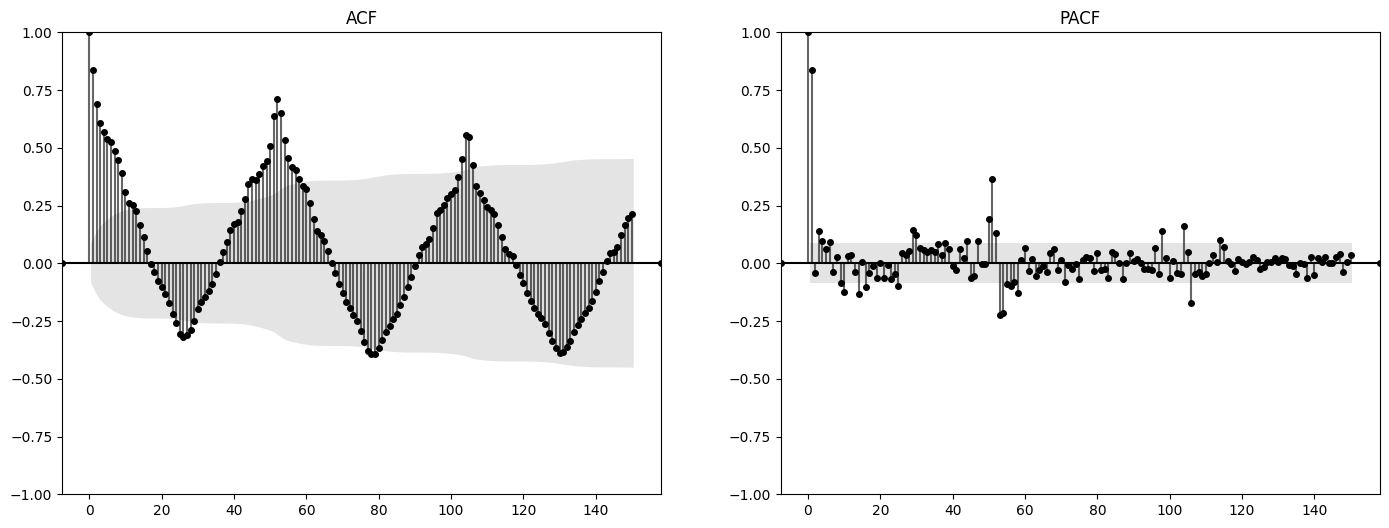

In [10]:
# e grafica ahora la acf de la train, se hace para rezagos cortos (20)
# Serie normal

plot_acf_pacf(train["value"], n_lags=150)


La ACF presenta un comportamiento decreciente alternado, con picos relevantes en rezagos múltiplos de 52. Esto sugiere que la serie puede requerir un diferenciamiento estacional. Mediante la serie diferenciada se examina de nuevo el periodograma, la ACF y la PACF para establecer candidatos para los demás órdenes

In [11]:
# diferenciación estacional 
train_copy = train.copy()
train_copy = train_copy.set_index("Start date")
train_stat_diff = train_copy.diff(52).dropna().reset_index()

train_stat_diff


,Start date,value
0,2016-01-04,-27346.778571
1,2016-01-11,-27328.607143
2,2016-01-18,22861.107143
3,2016-01-25,12482.714286
4,2016-02-01,-31650.785714
...,...,...
460,2024-10-28,-55807.678571
461,2024-11-04,-30979.392857
462,2024-11-11,-11783.428571
463,2024-11-18,48345.535714


se calcula el periodograma de la serie diferenciada para examinar las frecuencias relevantes

Periodo dominante estimado: 155.00


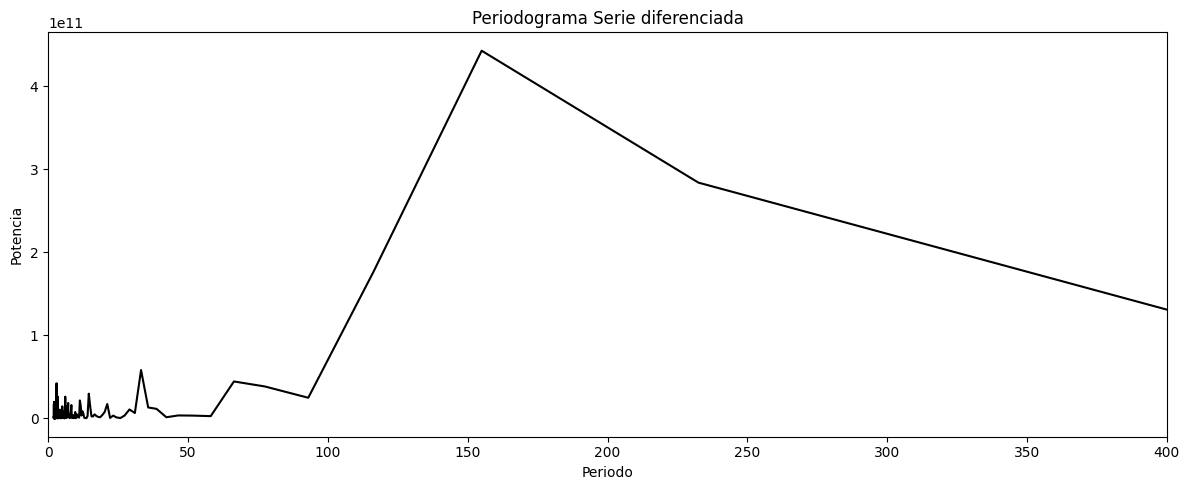

In [12]:
#periodograma
# 1. Preparación


train_diff_copy = train_stat_diff.sort_values("Start date").copy()
train_diff_copy["Start date"] = pd.to_datetime(train_diff_copy["Start date"])
train_diff_copy = train_diff_copy.set_index("Start date")

# Ajustar frecuencia
train_diff_copy = train_diff_copy.asfreq("W-MON") # frecuencia semanal con inicio el lunes (así se agrupo)

serie = train_diff_copy["value"].dropna().values

# 2. Periodograma clásico
fs = 1  # 1 observación por unidad temporal
frequencies, power = periodogram(serie, fs=fs)


# 3. Periodograma en términos de periodo
frequencies_nonzero = frequencies[1:]
power_nonzero = power[1:]

periods = 1 / frequencies_nonzero

# Detectar periodo dominante
idx_max = np.argmax(power_nonzero)
periodo_dominante = periods[idx_max]

print(f"Periodo dominante estimado: {periodo_dominante:.2f}")


# 4. Welch (suavizado)
frequencies_w, power_w = welch(serie, fs=1, nperseg=min(256, len(serie)))
frequencies_w_nz = frequencies_w[1:]
power_w_nz = power_w[1:]
periods_w = 1 / frequencies_w_nz


# 5. Gráficas

plt.figure(figsize=(12,5))
#plt.subplot(1,2,1)
plt.plot(periods, power_nonzero, color="black")
plt.title("Periodograma Serie diferenciada")
plt.xlabel("Periodo")
plt.ylabel("Potencia")
plt.xlim(0, min(400, periods.max()))
#plt.grid(True)

#plt.subplot(1,2,2)
#plt.plot(periods_w, power_w_nz)
#plt.title("Welch Periodogram")
##plt.xlabel("Periodo")
#plt.ylabel("Potencia")
#plt.xlim(0, min(400, periods_w.max()))
#plt.grid(True)

plt.tight_layout()
plt.show()

Tras la diferenciación estacional, desaparece el pico dominante asociado al período anualPersisten algunos picos de baja magnitud en períodos cortos; sin embargo, estos no presentan la prominencia ni la estabilidad suficientes para sustentar la existencia de una periodicidad secundaria claramente definida. Para validar que en efecto se eliminó la dependencia estacional, se grafica la ACF y la PACF de la serie diferenciada

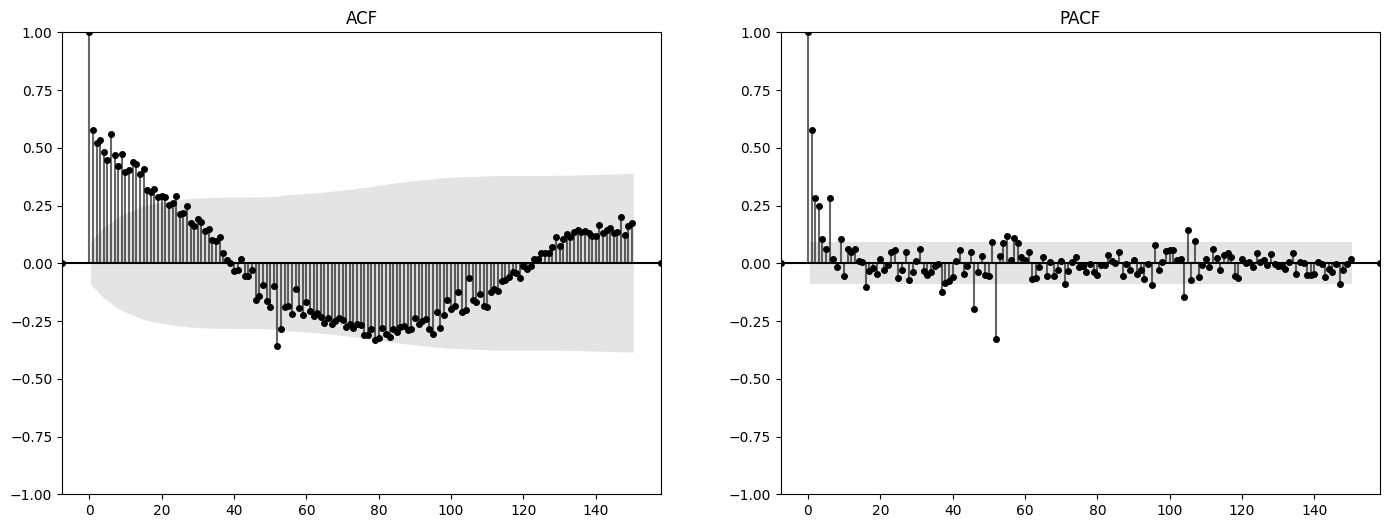

In [13]:
plot_acf_pacf(train_diff_copy["value"], n_lags=150)

Se observa que para los rezagos ks, no se presentan picos marcados como ocurria en la serie inicial. Esto indica que la componente estacional fue removida mediante la diferenciación, por lo que se toma D = 1. Se valida si la serie diferenciada es o no estacionaria

In [14]:
check_stationarity(train_diff_copy["value"])

ADF Statistic: -3.1403758789349809
p-value: 0.0237059326654897
Estacionaria


Nuevamente, dado que el valor p es menor a 0.05, se descarta la presencia de raíces unitarias en el proceso, indicando que la serie diferenciada es estacionaria. Respecto a los órdenes, De forma similar a la anterior, la ACF presenta un comportamiento decrenciente alternado mientras que para la PACF se muestra una dependencia significativa del rezago 1, donde posteriormente presenta un corte marcado. El comportamiento de la ACF y la PACF mencionados indican que la serie puede estar marcada por una componente autorregresiva, por lo que se propone de forma preliminar p = 1. Respecto a la componente de media móvil, dado el comportamiento de la ACF y la PACF no se presentan caracterizaciones que indiquen un comportamiento de media móvil de fondo, por lo que q = 0. Respecto a la excogencia preliminar de P, la ACF muestra un decaimiento en los rezagos estacionales, mientras que la PACF muestra un conrte significativo luego del rezago estacional 52, esto podría indicar que P = 1. Dado que no se encuentra evidencia para Q, se toma Q = 0. Así, un primer modelo candidato es de la forma $$SARIMA(1,0,0) \times (1,1,0)_{52}$$
que en su forma de operador es $$    $$ 

Aunque se sugiere que se requiere diferenciación estacional, se validan los resultados para los modelos con D=0 y D=1, junto con el comportamiento de los residuos 

### orden preliminar D = 0

In [15]:
# parametros iniciales
# fijar modelo manual
p1 = 1 # orden AR(p) no estacional
d1 = 0 # diferenciación no estacional
q1 = 0 # orden MA(q) no estacional
P1 = 1 # orden AR(P) estacional
Q1 = 0 # orden MA(Q) estacional
s = 52

In [16]:
# para D = 0
D1 = 0 
model_D1_0 = sm.tsa.statespace.SARIMAX(
        train["value"], 
        order = (p1,d1,q1), # ARIMA(p,d,q)
        seasonal_order= (P1,D1,Q1,s), # componentes estacionales
        enforce_invertibility=True, # representación invertible
        enforce_stationarity=True # representación que se acople a la estacionarieda
    )

results_model_D1_0 = model_D1_0.fit(method='lbfgs', maxiter=100, disp=False)
results_model_D1_0.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  517
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 52)   Log Likelihood               -6377.282
Date:                            Thu, 02 Apr 2026   AIC                          12760.564
Time:                                    17:25:22   BIC                          12773.308
Sample:                                         0   HQIC                         12765.557
                                            - 517                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9993      0.002    624.937      0.000       0.996       1.002
ar.S.L52       0.4566      0.029     15.824      0.000       0.400       0.513
sigma2      3.648e+09   2.96e-13   1.23e+22      0.000    3.65e+09    3.65e+09
===================================================================================
Ljung-Box (L1) (Q):                  32.49   Jarque-Bera (JB):               177.28
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.07   Skew:                            -0.00
Prob(H) (two-sided):                  0.64   Kurtosis:                         5.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.07e+38. Standard errors may be unstable.
"""

valor AIC: 12760.564
valor BIC: 12773.308

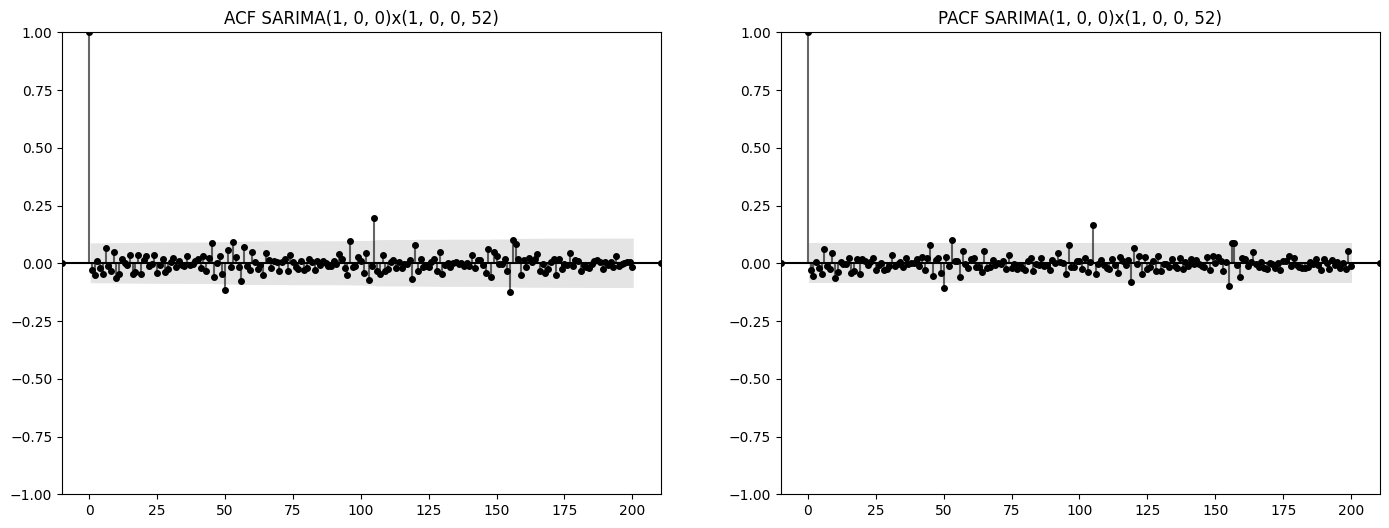

In [17]:
# analisis de residuos y test de ljung_box, QQ-plot
plot_acf_pacf(results_model_D1_0.resid, n_lags=200, title_graph=["ACF SARIMA(1, 0, 0)x(1, 0, 0, 52)", "PACF SARIMA(1, 0, 0)x(1, 0, 0, 52)"]) # ACF y pACF de residuops


Si se toma D = 0 como orden de diferenciaicón estacional, se aprecia que para los valores iniciales de los demás órdenes p,q,P,Q no hay correlaciones significativas entre los rezagos. se valida esto con la qqplot y el test de ljung-box para determiandos rezagos

In [18]:
n_lags = 200
arr_lags = [i for i in range(1,n_lags) ]

#print(acorr_ljungbox(results_model_D1_0.resid, lags=[10,20,40,52,60,80,104,105,106,107,108,109,110,111,112,113,114,124,134,144,156], return_df=True))
ljung_box_res = acorr_ljungbox(results_model_D1_0.resid, lags=arr_lags, return_df=True)

filtered_ljung_box_res = ljung_box_res[ljung_box_res["lb_pvalue"] < 0.05]
filtered_ljung_box_res

,lb_stat,lb_pvalue


para cada uno de los rezagos se aprecia que el valor p asociado al test es mayor al nivel de significancia (0.05).
Ljung-Box: H0: no hay autocorrelación hasta el lag h. Si el valor p es mayor al nivel de significancia (0.05), No se rechaza H0, es decir, no hay evidencia de autocorrelación residual entre los residuos. Puede verse entonces que aunque los valores de la ACF y la PACf están por fuera de los intervalos de confianza para los rezagos estacionales, para el test de ljung box el valor p hasta el rezago 200 es mayor al nivel de seginificancia, por lo que no se descarta la hipótesis nula, es decir, no hay autocorrelación significativa en los residuos. Se examina la qq plot

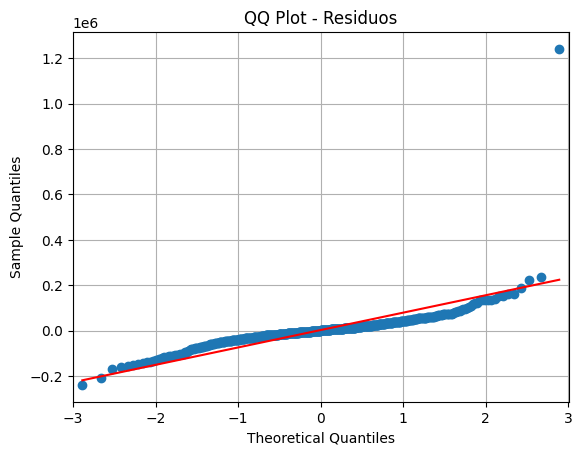

In [19]:
sm.qqplot(results_model_D1_0.resid, line="s")
plt.title("QQ Plot - Residuos")
plt.grid(True)
plt.show()

se aprecia que los cuantiles muestrales logran aproximarse de forma relativamente uniforme a los cuantiles teóricos, con unas leves desviaciones en las colas. Esto indica que los residuos siguen una distribución similar a los residuos teóricos, con una distribución simétrica. La sigera forma de s seguida por los cuantiles muestrales sugieren que la distribución de los residuos tiene colas ligeramente mas pesadas que la distribución que poseen los residuops teóricos, lo que indica que el modelo logra capturar bien la dimámica media de los datos pero existen valores extremos que el modelo no logra ajustar bien. Los valores extremos muestran ligeras diferencias en la distribución. Para validar lo anterior, se grafica el histograma

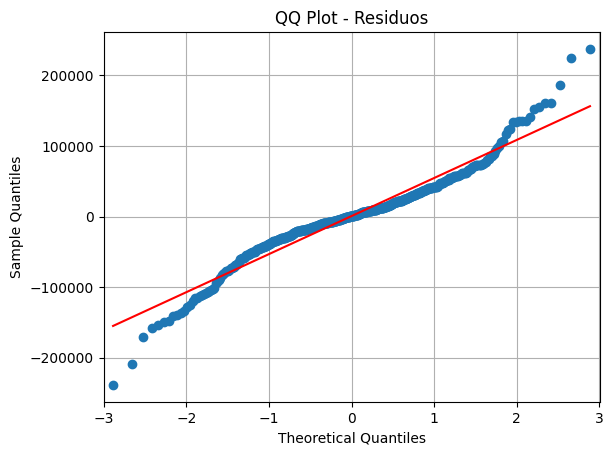

In [20]:
sm.qqplot(results_model_D1_0.resid[1:], line="s")
plt.title("QQ Plot - Residuos")
plt.grid(True)
plt.show()

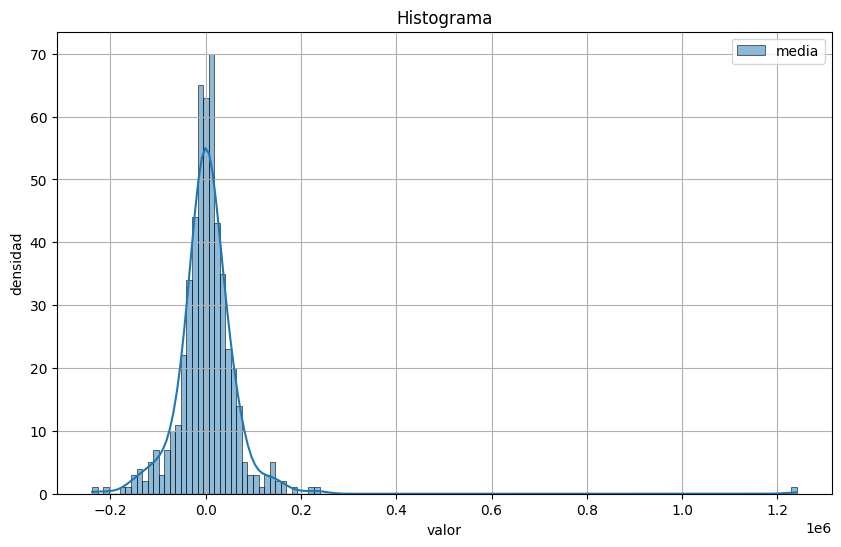

In [21]:
plt.figure(figsize=(10,6))
plt.hist(results_model_D1_0.resid, density=True, edgecolor='black', alpha=0.7)

# media
sns.histplot(results_model_D1_0.resid, kde=True,label='media')
plt.title("Histograma")
plt.xlabel("valor")
plt.ylabel("densidad")
plt.legend()
plt.grid()
plt.show()

puede verse que la distribución muestral que siguen los residuos es unimodal y simétrica, donde la mayoría de los residuos se concentran alrededor del cero. Esto se ve reflejado por la curva dada a partir de la estimación de densidad de kernel que permite encontrar la forma de la distribución que sigue un conjunto de datos dado. Se tiene un valor atípico cerca del valor $1.2 \times 10^6, lo que indica una asimetría positiva en la distribución. 

### Orden preliminar D = 1

se realiza el procedimiento anterior con D = 1

In [22]:
# fijar modelo manual
D1 = 1 # diferenciación estacional
model_D1_1 = sm.tsa.statespace.SARIMAX(
    train["value"], 
    order = (p1, d1, q1), # ARIMA(p,d,q)
    seasonal_order= (P1, D1, Q1, s), # componentes estacionales
    enforce_invertibility=True, # representación invertible
    enforce_stationarity=True # representación que se acople a la estacionarieda
)

results_model_D1_1 = model_D1_1.fit(method='lbfgs', maxiter=100, disp=False)
results_model_D1_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  517
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 52)   Log Likelihood               -5785.361
Date:                            Thu, 02 Apr 2026   AIC                          11576.722
Time:                                    17:25:54   BIC                          11589.148
Sample:                                         0   HQIC                         11581.613
                                            - 517                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3667      0.010     35.009      0.000       0.346       0.387
ar.S.L52      -0.0216      0.010     -2.243      0.025      -0.041      -0.003
sigma2      3.056e+09   2.99e-13   1.02e+22      0.000    3.06e+09    3.06e+09
===================================================================================
Ljung-Box (L1) (Q):                   8.69   Jarque-Bera (JB):               917.99
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.34   Skew:                            -0.61
Prob(H) (two-sided):                  0.07   Kurtosis:                         9.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.08e+37. Standard errors may be unstable.
"""

para el modelo SARIMA con D = 0:
- valor AIC: 12760.564
- valor BIC: 12773.308

para el modelo SARIMA con D = 1:
- valor AIC: 11576.722
- valor BIC: 11589.148

Se resalta que para D = 1 el valor tanto del AIC como del BIC dieron significativamente menores que los respectivos valores para D = 0. Realizamos el mismo procedimiento que el realizado para los residuos con D = 0.

Examinamos la acf y la pacf de los residuos

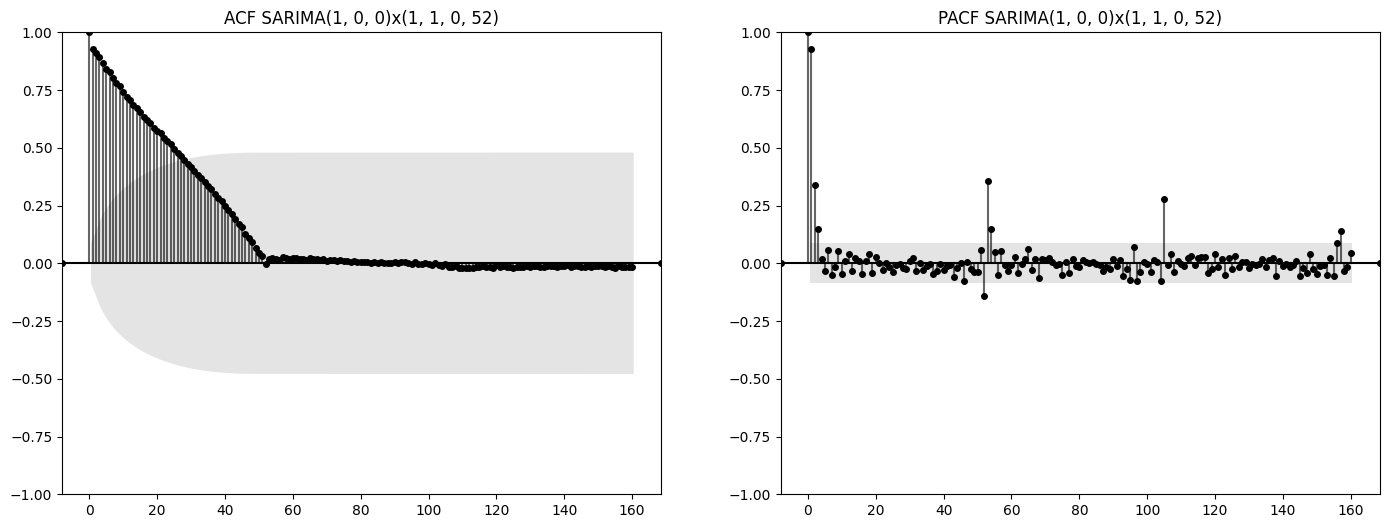

In [23]:
# analisis de residuos y test de ljung_box, QQ-plot
plot_acf_pacf(results_model_D1_1.resid, n_lags=160, title_graph=["ACF SARIMA(1, 0, 0)x(1, 1, 0, 52)", "PACF SARIMA(1, 0, 0)x(1, 1, 0, 52)"]) # ACF y pACF de residuops


A diferencia del caso D = 0, se tiene que la ACf muestra correlaciones significativas para los rezagos de 1 a 25-30 aproximadamente, mientras que la PACF muestra picos significativos en los rezagos estacionales, además de los primeros 3 rezagos. Aplicamos el test de ljung-box para examinar la correlación entr residuos hasta el rezago 200

In [24]:
n_lags = 200
arr_lags = [i for i in range(1,n_lags) ]
#arr_lags =[1,2,3,4,5,10,20,40,52,60,80,104,105,106,107,108,109,110,111,112,113,114,124,134,144,156]

#print(acorr_ljungbox(results_model_D1_0.resid, lags=[10,20,40,52,60,80,104,105,106,107,108,109,110,111,112,113,114,124,134,144,156], return_df=True))
ljung_box_res = acorr_ljungbox(results_model_D1_1.resid, lags=arr_lags, return_df=True)

filtered_ljung_box_res = ljung_box_res[ljung_box_res["lb_pvalue"] < 0.05]
filtered_ljung_box_res.head(30)

,lb_stat,lb_pvalue
1,448.863260,1.274977e-99
2,879.802591,8.980381e-192
3,1294.744871,2.032782e-280
4,1688.870830,0.000000e+00
5,2060.824025,0.000000e+00
6,2421.085034,0.000000e+00
7,2759.179536,0.000000e+00
8,3079.556239,0.000000e+00
9,3389.227186,0.000000e+00
10,3679.263824,0.000000e+00


In [25]:
filtered_ljung_box_res

,lb_stat,lb_pvalue
1,448.863260,1.274977e-99
2,879.802591,8.980381e-192
3,1294.744871,2.032782e-280
4,1688.870830,0.000000e+00
5,2060.824025,0.000000e+00
...,...,...
195,8019.542029,0.000000e+00
196,8021.594691,0.000000e+00
197,8023.780556,0.000000e+00
198,8025.781423,0.000000e+00


Nuevamente, a diferencia del caso D = 0, para D = 1 se tiene que el valor p del test de ljung-box hasta el rezago 200 es menor al nivel de significancia, lo que indica que para todos estos rezagos existe correlación significativa, lo que es consistente con el comportamiento visto en la ACf y la PACF. Ahora se examina la QQplot para validar el comportamiento de la distribución muestral. 

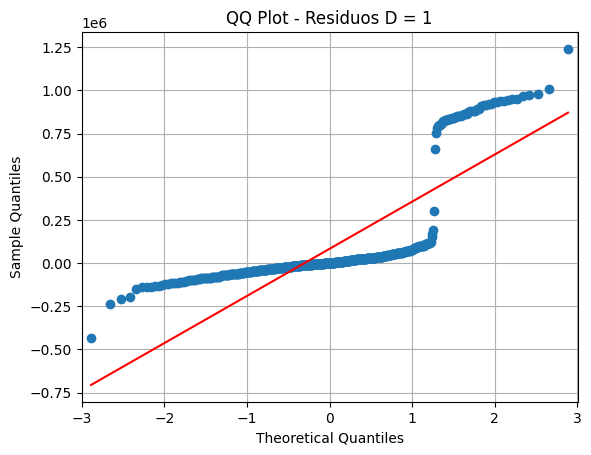

In [26]:
sm.qqplot(results_model_D1_1.resid, line="s")
plt.title("QQ Plot - Residuos D = 1")
plt.grid(True)
plt.show()

Se logra apreciar que existe una diferencia significativa para el caso D=1. La forma de s indica que la distribución muestral tiene colas mas pesadas y es una distribución mas asimétrica. Al haber puntos que difieren de forma relevante respecto a la distribución teórica, se tiene que la distribución muestral presenta una diferencia significativa respecto a la distribución teórica. Para validar lo anterior, se examina el histograma de los residuos

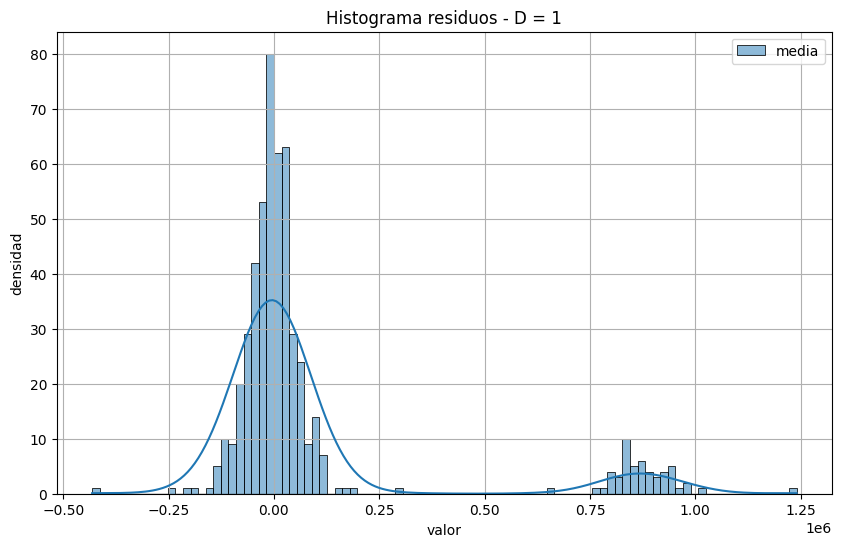

In [27]:
plt.figure(figsize=(10,6))
plt.hist(results_model_D1_1.resid, density=True, edgecolor='black', alpha=0.7)

# media
sns.histplot(results_model_D1_1.resid, kde=True,label='media')
plt.title("Histograma residuos - D = 1")
plt.xlabel("valor")
plt.ylabel("densidad")
plt.legend()
plt.grid()
plt.show()

Logra apreciarse que la distribución muestral obtenida mediante KDE para el caso D = 1 es bimodal, lo que es consistente con la asimetría arrojada por la gráfica QQplot. Esto indica que hay casos relevantes donde el modelo SARIMA con D = 1 no logra identificar el comportamiento de los datos. Esto sugiere que la diferenciación estacional introdujo correlación nueva que no estaba presente en el caso D = 0. Se tiene así que si se toma el orden estacional D = 1 se introducen distorsiones en la serie que resultan en un modelo que no se ajusta correctamente a los datos. Por ello se toma D = 0. Así, el modelo SARIMA $(1,0,0) \times (1,0,0)_{[52]}$ preliminar especificado es de la forma 

$$
 (1-\phi_1B)(1-\Phi_1B^{52})x_t = \delta + \omega_t
$$

siendo $\{ \omega_t \} $ una sucesión de variables aleatorias iid con media 0 y varianza finita.  

Con el objeto de encontrar un modelo SARIMA que se ajuste mejor a los datos de entrenamiento, se proponen otros modelos candidatos para evaluar el desempeño. Esto se hace mediante una busqueda de candidatos para los órdenes p, q, P, Q y examinar el valor del AIC para cada modelo junto con las métricas de error resultante, descartando los valores preliminares tomados anteriormente

In [28]:
p_train = p1
d_train = 0
q_train = q1
P_train = P1
D_train = 0
Q_train = Q1
s = 52
print(p_train)
print(d_train)
print(q_train)
print(P_train)
print(D_train)
print(Q_train)

1
0
0
1
0
0


In [29]:
dic_values = {
    "orden p": [], 
    "orden q": [], 
    "orden P":[], 
    "orden Q": [],
    "SARIMA": [], 
    "valor AIC": [],
    "valor BIC": [],
    "valor ljung_box": [],
    "valor p ljung_box min": []
    }

# se exluyen los órdenes p1, q1, P1, Q1 seleccionados previamente

#exclude_order = (p1,0,q1)
#exclude_seasonal = (P1,1,Q1,52)

# espacio reducido
p = q = range(0,2)
P = Q = range(0,2)

pdq = list(itertools.product(p, [d_train], q))
seasonal_pdq = list(itertools.product(P, [D_train], Q, [s]))

for param in pdq:
    for param_seasonal in seasonal_pdq:
        #if param == exclude_order and param_seasonal == exclude_seasonal:
        #    continue
        print(f"Probando SARIMA{param}x{param_seasonal}")
        start = time.time()
        try:
            model = sm.tsa.statespace.SARIMAX(
                train["value"],
                order=param,
                seasonal_order=param_seasonal,
                enforce_stationarity=True,
                enforce_invertibility=True
            )

            results = model.fit(
                method='lbfgs',
                maxiter=50,
                disp=False
            )


            elapsed = time.time() - start
            # analisis de residuos
            resid = results.resid.dropna()
            lb_test = acorr_ljungbox(resid, lags=[10,20,40,52,60,80,104,114,124,134,144,156], return_df=True)
            lb_stat = lb_test["lb_stat"].values
            lb_pvalues = lb_test["lb_pvalue"].values

            lb_stat_final = lb_stat[-1]          # o max
            lb_pvalue_final = lb_pvalues.min()  # ← clave


            print(f"AIC: {results.aic:.2f} | BIC: {results.bic:.2f} | tiempo: {elapsed:.1f}s")

            # se añaden los órdenes encontrados para definir un df con los parámetros 
            dic_values["orden p"].append(param[0])
            dic_values["orden q"].append(param[2])
            dic_values["orden P"].append(param_seasonal[0])
            dic_values["orden Q"].append(param_seasonal[2])
            
            dic_values["SARIMA"].append(f"SARIMA({param[0]},0,{param[2]})({param_seasonal[0]},0,{param_seasonal[2]})_52")
            dic_values["valor AIC"].append(round(results.aic, 4))
            dic_values["valor BIC"].append(round(results.bic, 4))
            dic_values["valor ljung_box"].append(lb_stat_final)
            dic_values["valor p ljung_box min"].append(lb_pvalue_final)
        
        except Exception as e:
            print("Error:", e)
            continue



Probando SARIMA(0, 0, 0)x(0, 0, 0, 52)
AIC: 16063.73 | BIC: 16067.98 | tiempo: 0.1s
Probando SARIMA(0, 0, 0)x(0, 0, 1, 52)
AIC: 15767.71 | BIC: 15776.20 | tiempo: 1.3s
Probando SARIMA(0, 0, 0)x(1, 0, 0, 52)
AIC: 13289.91 | BIC: 13298.41 | tiempo: 1.5s
Probando SARIMA(0, 0, 0)x(1, 0, 1, 52)
AIC: 13225.48 | BIC: 13238.23 | tiempo: 5.5s
Probando SARIMA(0, 0, 1)x(0, 0, 0, 52)
AIC: 15688.62 | BIC: 15697.12 | tiempo: 0.1s
Probando SARIMA(0, 0, 1)x(0, 0, 1, 52)
AIC: 15634.03 | BIC: 15646.78 | tiempo: 2.6s
Probando SARIMA(0, 0, 1)x(1, 0, 0, 52)
AIC: 15605.25 | BIC: 15618.00 | tiempo: 2.2s
Probando SARIMA(0, 0, 1)x(1, 0, 1, 52)
AIC: 15602.89 | BIC: 15619.88 | tiempo: 4.1s
Probando SARIMA(1, 0, 0)x(0, 0, 0, 52)
AIC: 12860.26 | BIC: 12868.75 | tiempo: 0.1s
Probando SARIMA(1, 0, 0)x(0, 0, 1, 52)
AIC: 12785.26 | BIC: 12798.00 | tiempo: 1.9s
Probando SARIMA(1, 0, 0)x(1, 0, 0, 52)
AIC: 12760.56 | BIC: 12773.31 | tiempo: 1.5s
Probando SARIMA(1, 0, 0)x(1, 0, 1, 52)
AIC: 12729.21 | BIC: 12746.20 | tiemp

In [30]:
lb_pvalue_final

0.019448842287907733

In [31]:
df_ordenes = pd.DataFrame(dic_values).sort_values(by='valor AIC')
df_ordenes = df_ordenes.drop(columns={"valor BIC"})
df_ordenes["valor p ljung_box min"] = df_ordenes["valor p ljung_box min"].round(4)
df_ordenes

,orden p,orden q,orden P,orden Q,SARIMA,valor AIC,valor ljung_box,valor p ljung_box min
15,1,1,1,1,"SARIMA(1,0,1)(1,0,1)_52",12657.5047,97.783171,0.0194
14,1,1,1,0,"SARIMA(1,0,1)(1,0,0)_52",12693.4766,104.588372,0.0345
11,1,0,1,1,"SARIMA(1,0,0)(1,0,1)_52",12729.2077,137.370898,0.5714
10,1,0,1,0,"SARIMA(1,0,0)(1,0,0)_52",12760.5636,153.024958,0.4867
13,1,1,0,1,"SARIMA(1,0,1)(0,0,1)_52",12760.7640,152.987935,0.1313
9,1,0,0,1,"SARIMA(1,0,0)(0,0,1)_52",12785.2562,167.211921,0.2554
8,1,0,0,0,"SARIMA(1,0,0)(0,0,0)_52",12860.2583,294.647306,0.0000
12,1,1,0,0,"SARIMA(1,0,1)(0,0,0)_52",12861.6462,303.547477,0.0000
3,0,0,1,1,"SARIMA(0,0,0)(1,0,1)_52",13225.4839,8621.566346,0.0000
2,0,0,1,0,"SARIMA(0,0,0)(1,0,0)_52",13289.9149,8533.532171,0.0000


In [32]:
# se filtran por aquelos que tienen valor p min mayor a 0.05
df_ordenes[df_ordenes["valor p ljung_box min"] > 0.05]

,orden p,orden q,orden P,orden Q,SARIMA,valor AIC,valor ljung_box,valor p ljung_box min
11,1,0,1,1,"SARIMA(1,0,0)(1,0,1)_52",12729.2077,137.370898,0.5714
10,1,0,1,0,"SARIMA(1,0,0)(1,0,0)_52",12760.5636,153.024958,0.4867
13,1,1,0,1,"SARIMA(1,0,1)(0,0,1)_52",12760.7640,152.987935,0.1313
9,1,0,0,1,"SARIMA(1,0,0)(0,0,1)_52",12785.2562,167.211921,0.2554


In [33]:
# se extrae el registro del df anterior que corresponde a la configuración preliminar de p,q,P,Q

df_ordenes[
    (df_ordenes["orden p"] == p1) &
    (df_ordenes["orden q"] == q1) &
    (df_ordenes["orden P"] == P1) &
    (df_ordenes["orden Q"] == Q1) 
    ]

,orden p,orden q,orden P,orden Q,SARIMA,valor AIC,valor ljung_box,valor p ljung_box min
10,1,0,1,0,"SARIMA(1,0,0)(1,0,0)_52",12760.5636,153.024958,0.4867


In [34]:
df_ordenes.head(1)["SARIMA"].values[0]

'SARIMA(1,0,1)(1,0,1)_52'

al iterar por los posibles órdenes de p, q, P ,Q definidos antes, se encuentra que existen 3 opciones que presentan mejoras significativas en el valor del AIC. Para cada uno, se examina el comportamiento de los residuos de la misma forma que se hizo para D = 0 y D = 1

In [35]:
df_ordenes.head(10)

,orden p,orden q,orden P,orden Q,SARIMA,valor AIC,valor ljung_box,valor p ljung_box min
15,1,1,1,1,"SARIMA(1,0,1)(1,0,1)_52",12657.5047,97.783171,0.0194
14,1,1,1,0,"SARIMA(1,0,1)(1,0,0)_52",12693.4766,104.588372,0.0345
11,1,0,1,1,"SARIMA(1,0,0)(1,0,1)_52",12729.2077,137.370898,0.5714
10,1,0,1,0,"SARIMA(1,0,0)(1,0,0)_52",12760.5636,153.024958,0.4867
13,1,1,0,1,"SARIMA(1,0,1)(0,0,1)_52",12760.7640,152.987935,0.1313
9,1,0,0,1,"SARIMA(1,0,0)(0,0,1)_52",12785.2562,167.211921,0.2554
8,1,0,0,0,"SARIMA(1,0,0)(0,0,0)_52",12860.2583,294.647306,0.0000
12,1,1,0,0,"SARIMA(1,0,1)(0,0,0)_52",12861.6462,303.547477,0.0000
3,0,0,1,1,"SARIMA(0,0,0)(1,0,1)_52",13225.4839,8621.566346,0.0000
2,0,0,1,0,"SARIMA(0,0,0)(1,0,0)_52",13289.9149,8533.532171,0.0000


### Modelos 

Dado que ya se tiene el valor del AIC y el BIC para cada modelo, se requiere ahora es examinar el comportamiento de la ACf y la PACf así como los valores para el test de ljung-box

In [36]:
df_models_params = df_ordenes[df_ordenes["valor p ljung_box min"] > 0.05]

#p_orders = df_models_params["orden p"].values
#q_orders = df_models_params["orden Q"].values
#P_orders = df_models_params["orden P"].values
#Q_orders = df_models_params["orden Q"].values
#
## arrays de ordenes para d y D (arrays nulos dado que d = D = 0)
#d_orders = [0 for _ in range(len(p_orders))]
#D_orders = [0 for _ in range(len(p_orders))]

dict_models_residuals = {}



for _, row in df_models_params.iterrows():
    
    p = row["orden p"]
    q = row["orden q"]
    P = row["orden P"]
    Q = row["orden Q"]

    model_train =  sm.tsa.statespace.SARIMAX(
        train["value"], 
        order = (p, 0, q), # ARIMA(p,d,q)
        seasonal_order= (P, 0, Q, s), # componentes estacionales
        enforce_invertibility=True, # representación invertible
        enforce_stationarity=True # representación que se acople a la estacionarieda
    )

    results_train = model_train.fit(method='lbfgs', maxiter=100, disp=False)
    
    model_name = f"SARIMA({p}, 0, {q})({P}, 0, {Q})_{s}"
    dict_models_residuals[model_name] = results_train.resid.dropna()
    


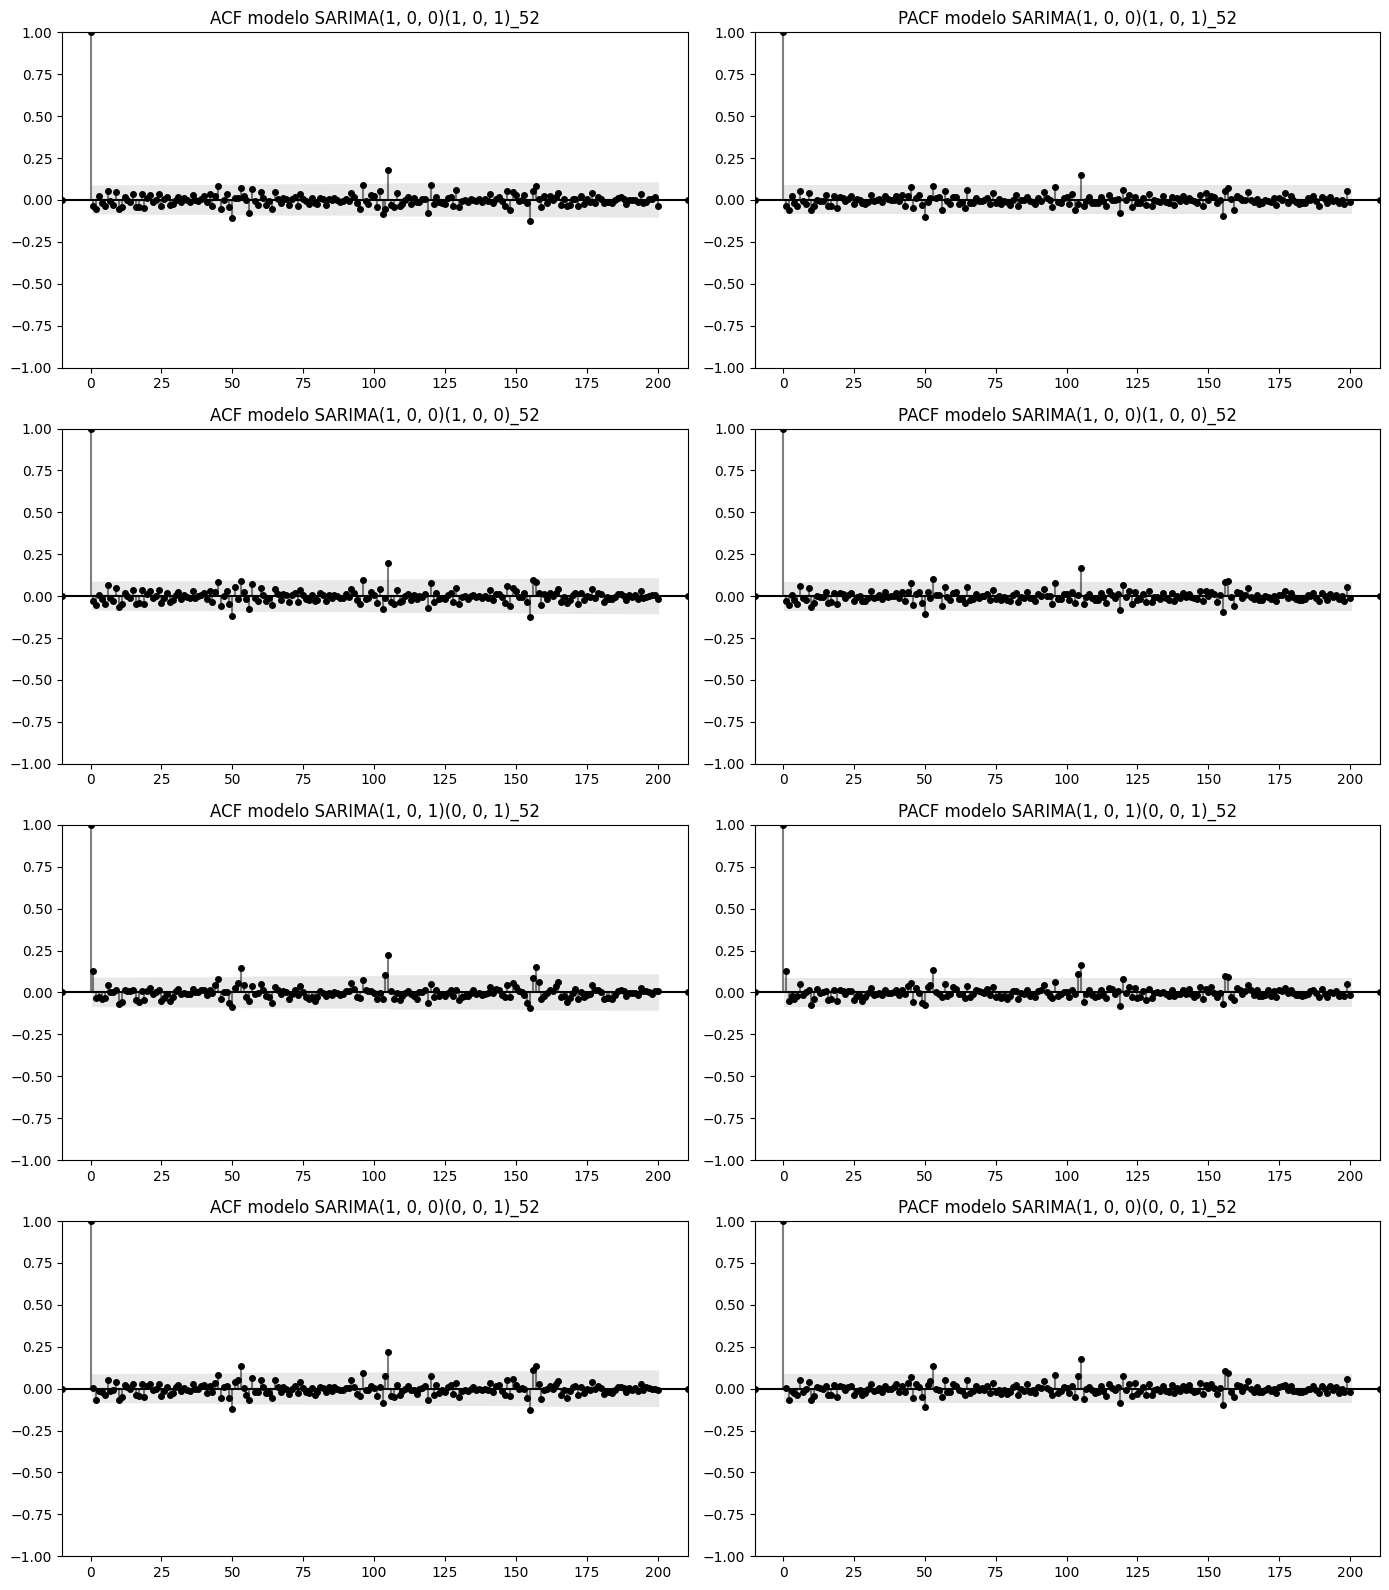

In [37]:
n_models = len(dict_models_residuals)

fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models))

for i, (key, value) in enumerate(dict_models_residuals.items()):
    
    plot_acf(value, ax=axes[i, 0], lags=200, alpha=0.05,
        vlines_kwargs={"colors": "black"},
        marker="o",
        color="black",
        markersize=4)
    axes[i, 0].set_title(f"ACF modelo {key}")
    
    plot_pacf(value, ax=axes[i, 1], lags=200, method="ywm", alpha=0.05,
        vlines_kwargs={"colors": "black"},
        marker="o",
        color="black",
        markersize=4)
    axes[i, 1].set_title(f"PACF modelo {key}")
    
    # cambiar color de bandas
    for ax in [axes[i, 0], axes[i, 1]]:
        for collection in ax.collections:
            collection.set_facecolor("lightgray")   # color
            collection.set_alpha(0.5)               # transparencia

plt.tight_layout()
plt.show()

In [38]:
n_lags = 200
arr_lags = [i for i in range(1,n_lags) ]

#print(acorr_ljungbox(results_model_D1_0.resid, lags=[10,20,40,52,60,80,104,105,106,107,108,109,110,111,112,113,114,124,134,144,156], return_df=True))


for key, value in dict_models_residuals.items():
    ljung_box_res_train = acorr_ljungbox(value, lags=arr_lags, return_df=True)

    filtered_ljung_box_res_train = ljung_box_res_train[ljung_box_res_train["lb_pvalue"] < 0.05]
    print(f" {key}: \n")
    if len(filtered_ljung_box_res_train) > 0:
        print(f"array con valor p < 0.05 test ljung-box {key}: \n")
        print(filtered_ljung_box_res_train)
    

 SARIMA(1, 0, 0)(1, 0, 1)_52: 

 SARIMA(1, 0, 0)(1, 0, 0)_52: 

 SARIMA(1, 0, 1)(0, 0, 1)_52: 

array con valor p < 0.05 test ljung-box SARIMA(1, 0, 1)(0, 0, 1)_52: 

     lb_stat  lb_pvalue
1   8.639130   0.003290
2   9.220551   0.009949
3   9.674654   0.021544
4  10.582191   0.031683
5  11.087735   0.049668
 SARIMA(1, 0, 0)(0, 0, 1)_52: 



SARIMA(1, 0, 1)(0, 0, 1)_52 presenta correlaciones para los primeros 5 rezagos. El modelo SARIMA(1, 0, 0)(1, 0, 1)_52 no presenta correlaciones significativas y el modelo SARIMA(1, 0, 0)(1, 0, 0)_52 es la opción preliminar, y SARIMA(1, 0, 0)(0, 0, 1)_52 tampoco presenta correlaciones. Se examinan los modelos restantes 

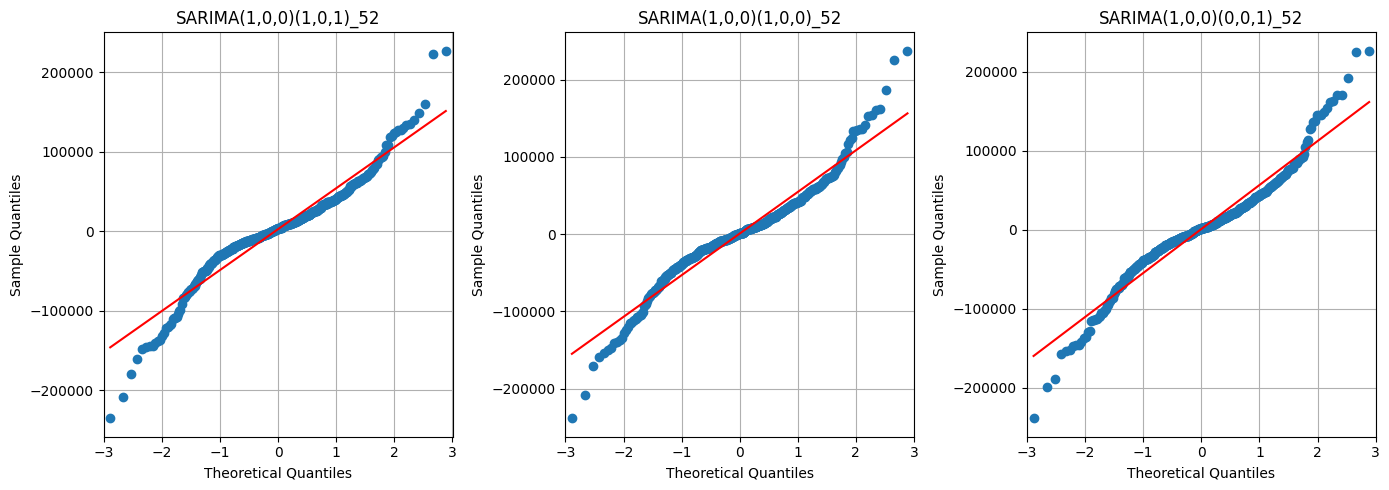

In [61]:
# compración modelo preliminar vs modelo alt
fig, axes = plt.subplots(1, 3, figsize=(14,5))

# Modelo 1
sm.qqplot(
    dict_models_residuals["SARIMA(1, 0, 0)(1, 0, 1)_52"][1:], 
    line="s", 
    ax=axes[0]
)
axes[0].set_title("SARIMA(1,0,0)(1,0,1)_52")
axes[0].grid(True)

# Modelo 2
sm.qqplot(
    dict_models_residuals["SARIMA(1, 0, 0)(1, 0, 0)_52"][1:], 
    line="s", 
    ax=axes[1]
)
axes[1].set_title("SARIMA(1,0,0)(1,0,0)_52")
axes[1].grid(True)

# Modelo 3
sm.qqplot(
    dict_models_residuals["SARIMA(1, 0, 0)(0, 0, 1)_52"][1:], 
    line="s", 
    ax=axes[2]
)
axes[2].set_title("SARIMA(1,0,0)(0,0,1)_52")
axes[2].grid(True)
plt.tight_layout()
plt.show()

comportamiento similar al visto en el modelo preliminar. Se mira el histograma

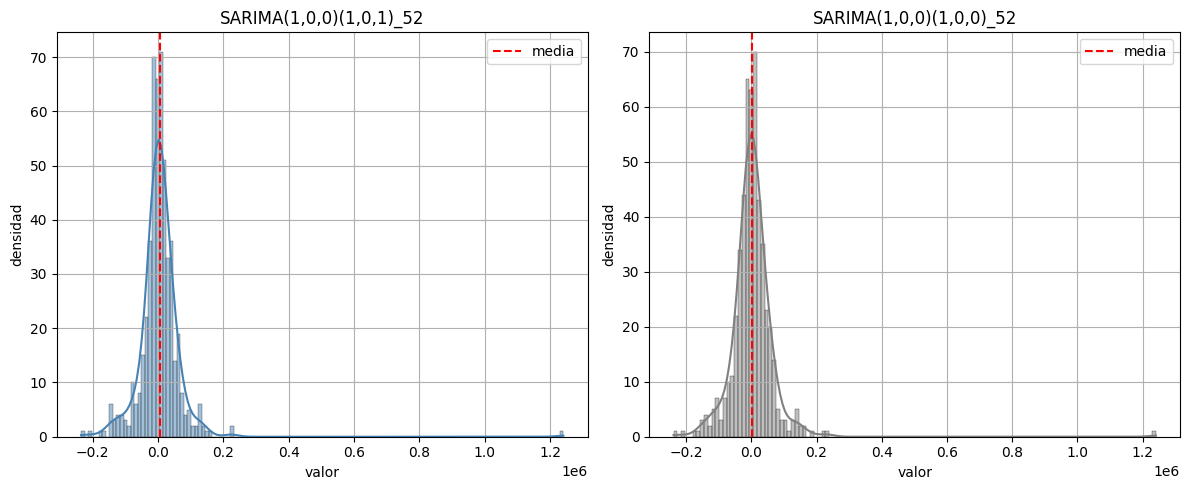

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Modelo 1
res1 = dict_models_residuals["SARIMA(1, 0, 0)(1, 0, 1)_52"]

sns.histplot(res1, kde=True, ax=axes[0], color="steelblue", edgecolor="black")
axes[0].axvline(res1.mean(), color="red", linestyle="--", label="media")
axes[0].set_title("SARIMA(1,0,0)(1,0,1)_52")
axes[0].set_xlabel("valor")
axes[0].set_ylabel("densidad")
axes[0].legend()
axes[0].grid(True)

# Modelo 2
res2 = dict_models_residuals["SARIMA(1, 0, 0)(1, 0, 0)_52"]

sns.histplot(res2, kde=True, ax=axes[1], color="gray", edgecolor="black")
axes[1].axvline(res2.mean(), color="red", linestyle="--", label="media")
axes[1].set_title("SARIMA(1,0,0)(1,0,0)_52")
axes[1].set_xlabel("valor")
axes[1].set_ylabel("densidad")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

ambos poseen un comportamiento muy similar en distribución, con el mismo valor atípico. Las colas de la distribucion de la dercha varian un poco respecto a las de la izquierda, pero en general ambols modelos tiene un comportamiento muy parecido. Dado que el modelo SARIMA(1,0,0)(1,0,1)_52 tiene menor AIC que el SARIMA(1,0,0)(1,0,0)_52 y presenta un comportamiento consistente respecto a valores de residuos y análisis, se toma el modelo SARIMA(1,0,0)(1,0,1)_52 como modelo final. Ahora se valida la predicción

In [41]:
params_final = df_models_params[df_models_params.index == 11]

p_final = params_final["orden p"].values[0]
d_final = 0
q_final = params_final["orden q"].values[0]
P_final = params_final["orden P"].values[0]
D_final = 0
Q_final = params_final["orden Q"].values[0]


In [42]:
# definición de órdenes y fijado del modelo 


print(f"orden p final: {p_final}")
print(f"orden d final: {d_final}")
print(f"orden q final: {q_final}")
print(f"orden P final: {P_final}")
print(f"orden D final: {D_final}")
print(f"orden Q final: {Q_final}")



orden p final: 1
orden d final: 0
orden q final: 0
orden P final: 1
orden D final: 0
orden Q final: 1


la estructura del modelo es de la forma $$(1- \phi_1 B)(1- \Phi_1 B^{52})x_t = \delta + (1+\Theta_1^{52})\omega_t $$
se hallan los coeficientes

In [43]:
model_final =  sm.tsa.statespace.SARIMAX(
        train["value"], 
        order = (p_final, d_final, q_final), # ARIMA(p,d,q)
        seasonal_order= (P_final, D_final, Q_final, s), # componentes estacionales
        enforce_invertibility=True, # representación invertible
        enforce_stationarity=True # representación que se acople a la estacionarieda
    )

results_final = model_final.fit(method='lbfgs', maxiter=100, disp=False)
results_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                value   No. Observations:                  517
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 52)   Log Likelihood               -6360.604
Date:                              Thu, 02 Apr 2026   AIC                          12729.208
Time:                                      17:27:23   BIC                          12746.200
Sample:                                           0   HQIC                         12735.866
                                              - 517                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9945      0.007    134.246      0.000       0.980       1.009
ar.S.L52       0.8529      0.041     20.645      0.000       0.772       0.934
ma.S.L52      -0.5391      0.068     -7.903      0.000      -0.673      -0.405
sigma2      3.648e+09   4.54e-12   8.04e+20      0.000    3.65e+09    3.65e+09
===================================================================================
Ljung-Box (L1) (Q):                  39.77   Jarque-Bera (JB):               218.93
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.03   Skew:                            -0.29
Prob(H) (two-sided):                  0.86   Kurtosis:                         6.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.33e+36. Standard errors may be unstable.
"""

coeficientes:
- $\phi_1: 0.9945$
- $\Phi_1: 0.8529$
- $\Theta_1: -0.5391$
- valor AIC: 12729.208

In [44]:
# se ve que pasa con el valor atipico de la grafica de cuantiles
train_series = train.set_index("Start date")["value"]

residuals = results_final.resid.dropna()

outliers = residuals.sort_values(ascending=False).head(5)

print(outliers)

0      1.240580e+06
1      2.269722e+05
327    2.226283e+05
432    1.601948e+05
120    1.480700e+05
dtype: float64


In [45]:
train["value"].head(1).values[0] == residuals[0]

True

se observa que el primer residuo (de orden de 10^6) es el primer valor obtenido respecto al conjunto de datos de entrenamiento, que coincide con el punto atípico visto en la gráfica QQ-plot. Los demás órdenes presentan un comportamiento consistente con lo visto en la grafica inicial. A modo de validación, se elemina dicho residuo para ver el comportamienot de los demás 

<Figure size 600x500 with 0 Axes>

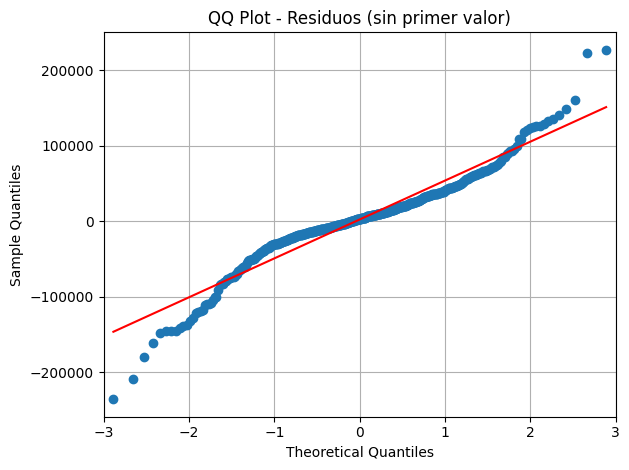

In [46]:
# compración modelo preliminar vs modelo alt

residuals_clean = residuals.iloc[1:]


plt.figure(figsize=(6,5))

sm.qqplot(
    residuals_clean,
    line="s"
)

plt.title("QQ Plot - Residuos (sin primer valor)")
plt.grid(True)

plt.tight_layout()
plt.show()

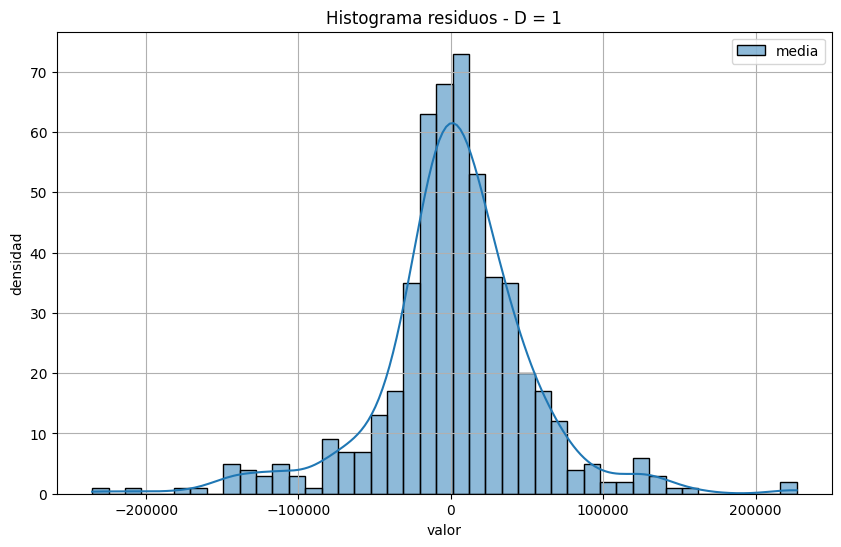

In [47]:
plt.figure(figsize=(10,6))
plt.hist(residuals_clean, density=True, edgecolor='black', alpha=0.7)

# media
sns.histplot(residuals_clean, kde=True,label='media')
plt.title("Histograma residuos - D = 1")
plt.xlabel("valor")
plt.ylabel("densidad")
plt.legend()
plt.grid()
plt.show()

El QQ plot evidencia que, si bien los residuos se ajustan adecuadamente a la normalidad en la región central, presentan desviaciones en las colas, lo que indica la presencia de colas pesadas. Esto sugiere que el modelo SARIMA captura adecuadamente la dinámica media de la serie, pero no modela completamente la ocurrencia de eventos extremos.


In [48]:
df_data_close.head()

,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


In [49]:
# predicciones
forecast_index = test.index
# Número de pasos a predecir
n_forecast = len(test)

forecast = results_final.get_forecast(steps=n_forecast)

# Media predicha
forecast_mean = forecast.predicted_mean

# Intervalos de confianza
forecast_ci = forecast.conf_int()

forecast_df = pd.DataFrame({
    "forecast": forecast_mean.values,
    "lower_ci": forecast_ci.iloc[:, 0].values,
    "upper_ci": forecast_ci.iloc[:, 1].values
}, index=forecast_index) 

forecast_df.head()

,forecast,lower_ci,upper_ci
517,1.468724e+06,1.350348e+06,1.587099e+06
518,1.453211e+06,1.286260e+06,1.620162e+06
519,1.427748e+06,1.223833e+06,1.631663e+06
520,1.321395e+06,1.086574e+06,1.556215e+06
521,1.259956e+06,9.981310e+05,1.521781e+06


In [50]:
# cálculo de errores
y_true = test["value"]
y_pred = forecast_df["forecast"]


smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true))
smape = smape_fn(y_true, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape*100:.4f}%")
print(f"sMAPE: {smape*100:.4f}%")


MAE: 51313.516011050466
RMSE: 63161.65201374075
MAPE: 4.0668%
sMAPE: 4.0362%


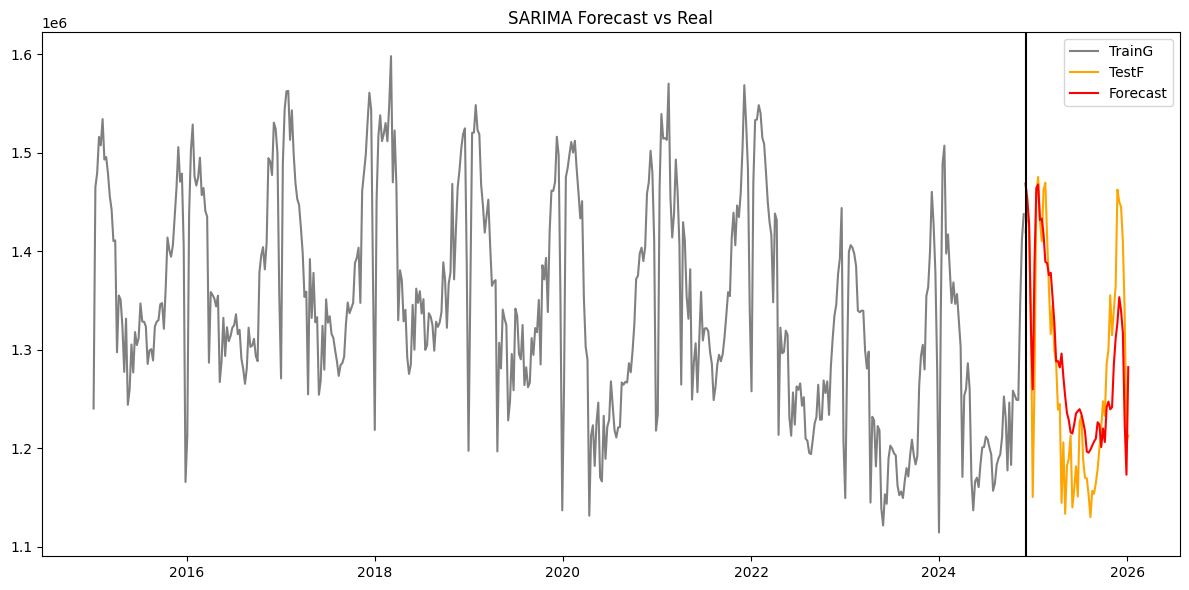

In [62]:
# Ajuste visual
plt.figure(figsize=(12,6))

# Datos reales
plt.plot(train["Start date"], train["value"], label="TrainG", color="gray")
plt.plot(test["Start date"], test["value"], label="TestF", color="orange")

# Predicción
plt.plot(test["Start date"], forecast_df["forecast"], 
         label="Forecast", color="red")


#linea

plt.axvline(test["Start date"].values[0], color="black")
""" # Intervalos
plt.fill_between(
    test["Start date"],
    forecast_df["lower_ci"],
    forecast_df["upper_ci"],
    color="red",
    alpha=0.2
) """

plt.legend()
plt.title("SARIMA Forecast vs Real")
#plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
y_pred[0+len(train)]


1468723.6230803947

In [53]:
arr_preds = []
for index, value in enumerate(test["Start date"].values):
    dict_pred = {
        "Date": np.datetime_as_string(value, unit="D"), # convierte a la fecha a string para poder exportar a json
        "pred" : float(y_pred[index + len(train)])
    }
    arr_preds.append(dict_pred)
arr_preds

[{'Date': '2024-12-02', 'pred': 1468723.6230803947},
 {'Date': '2024-12-09', 'pred': 1453211.3125101933},
 {'Date': '2024-12-16', 'pred': 1427748.0804383012},
 {'Date': '2024-12-23', 'pred': 1321394.6343503692},
 {'Date': '2024-12-30', 'pred': 1259955.8808884707},
 {'Date': '2025-01-06', 'pred': 1388625.1341616248},
 {'Date': '2025-01-13', 'pred': 1464342.2978547635},
 {'Date': '2025-01-20', 'pred': 1467921.4771457885},
 {'Date': '2025-01-27', 'pred': 1431806.7210661848},
 {'Date': '2025-02-03', 'pred': 1433361.8702524824},
 {'Date': '2025-02-10', 'pred': 1417212.9387539295},
 {'Date': '2025-02-17', 'pred': 1389440.1198691414},
 {'Date': '2025-02-24', 'pred': 1387927.541462667},
 {'Date': '2025-03-03', 'pred': 1375799.6975810383},
 {'Date': '2025-03-10', 'pred': 1378295.1080033465},
 {'Date': '2025-03-17', 'pred': 1353564.1954875607},
 {'Date': '2025-03-24', 'pred': 1327815.4737180097},
 {'Date': '2025-03-31', 'pred': 1288301.808553169},
 {'Date': '2025-04-07', 'pred': 1288684.50130037

In [54]:
# Cálculo de métricas agregadas
dict_to_export = {
    "mape_val": float(mape),
    "mae_val": float(mae),
    "smape_val": float(smape),
    "rmse_val": float(rmse),
    "predictions": arr_preds
}
#with open ("../../../data/preds_energy_models/SARIMA_preds.json", "w") as json_file:
#    json.dump(dict_to_export, json_file, indent=4)